In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

# format all floating-point numbers to 2 decimal places when displaying them in tables
pd.set_option('display.float_format', lambda x: '%.2f' % x)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
csv_file = '/content/drive/MyDrive/UTP/2024/s107_Proyector_Integrador_1/final_project/notebooks/data/US_Accidents_FL.csv'

traffic_accidents_raw = pd.read_csv(csv_file) # leemos el dataset


### 🔍 Análisis Exploratorio (EDA)

El dataset US Accidents fue filtrado para el estado de **Florida**,
seleccionado por su similitud climática y estructural con Panamá
(clima subtropical, infraestructura mixta urbana/rural, geografía costera).
La granularidad geográfica se trabaja a nivel de County y City.

In [33]:
# Prints the columns name as a list
traffic_accidents_raw.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [34]:
# Checking the Length of Number of Columns
len(traffic_accidents_raw.columns)

46

In [35]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']

numeric_df = traffic_accidents_raw.select_dtypes(include=numerics)
len(numeric_df.columns)

13

In [36]:
traffic_accidents_raw.head(3)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-116062,Source2,3,2016-11-30 15:36:03,2016-11-30 17:09:22,27.98,-82.33,27.41,-81.33,0.01,Queueing traffic and two left lane blocked due to accident on I-75 Southbound after Exits 260 260A 260B FL-574 Dr Martin Luther King Jr Blvd.,E Dr Martin Luther King Jr Blvd,Tampa,Hillsborough,FL,33610,US,US/Eastern,KVDF,2016-11-30 15:35:00,80.60,77.00,70.00,29.94,10.00,SSW,5.80,0.00,Overcast,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
1,A-116063,Source2,3,2016-11-30 16:25:35,2016-11-30 17:12:25,27.98,-82.33,27.41,-81.33,0.01,Queueing traffic and 2 left lane closed due to accident on I-75 Southbound at Exits 260 260A 260B FL-574 Dr Martin Luther King Jr Blvd.,E Dr Martin Luther King Jr Blvd,Tampa,Hillsborough,FL,33610,US,US/Eastern,KVDF,2016-11-30 16:35:00,80.60,77.00,65.00,29.94,10.00,WSW,6.90,0.00,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day
2,A-116064,Source2,2,2016-11-30 16:40:31,2016-11-30 17:10:19,25.63,-80.37,27.41,-81.33,0.01,Accident on FL-992 152nd St at Lincoln Blvd.,SW 152nd St,Miami,Miami-Dade,FL,33157-1147,US,US/Eastern,KTMB,2016-11-30 16:53:00,80.10,77.00,71.00,29.96,10.00,SE,9.20,0.00,Mostly Cloudy,False,False,True,False,False,False,False,False,False,True,False,True,False,Day,Day,Day,Day


In [37]:
traffic_accidents_raw.shape

(880192, 46)

In [38]:
traffic_accidents_raw.dtypes

,0
ID,object
Source,object
Severity,int64
Start_Time,object
End_Time,object
Start_Lat,float64
Start_Lng,float64
End_Lat,float64
End_Lng,float64
Distance(mi),float64


In [39]:
# Identificamos si hay valores nulos en el dataset
traffic_accidents_raw.isnull().sum()
missing_values = traffic_accidents_raw.isnull().sum()

missing_values

,0
ID,0
Source,0
Severity,0
Start_Time,0
End_Time,0
Start_Lat,0
Start_Lng,0
End_Lat,0
End_Lng,0
Distance(mi),0


In [40]:
number_columns = traffic_accidents_raw.select_dtypes(include = np.number).columns.to_list()
number_columns

['Severity',
 'Start_Lat',
 'Start_Lng',
 'End_Lat',
 'End_Lng',
 'Distance(mi)',
 'Temperature(F)',
 'Wind_Chill(F)',
 'Humidity(%)',
 'Pressure(in)',
 'Visibility(mi)',
 'Wind_Speed(mph)',
 'Precipitation(in)']

In [41]:
categorical_columns = traffic_accidents_raw.select_dtypes(include = "object").columns.to_list()
categorical_columns

['ID',
 'Source',
 'Start_Time',
 'End_Time',
 'Description',
 'Street',
 'City',
 'County',
 'State',
 'Zipcode',
 'Country',
 'Timezone',
 'Airport_Code',
 'Weather_Timestamp',
 'Wind_Direction',
 'Weather_Condition',
 'Sunrise_Sunset',
 'Civil_Twilight',
 'Nautical_Twilight',
 'Astronomical_Twilight']

In [42]:
# Tratamiento de valores nulos: rellenar con valores apropiados

# Para columnas numéricas, rellenamos con la mediana
for col in number_columns:
    median_value = traffic_accidents_raw[col].median()
    traffic_accidents_raw[col] = traffic_accidents_raw[col].fillna(median_value)

# Para columnas categóricas, rellenamos con la moda
for col in categorical_columns:
    mode_value = traffic_accidents_raw[col].mode()[0]
    traffic_accidents_raw[col] = traffic_accidents_raw[col].fillna(mode_value)

In [43]:
print("\nInformación general del dataset:")
traffic_accidents_raw.info()


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880192 entries, 0 to 880191
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     880192 non-null  object 
 1   Source                 880192 non-null  object 
 2   Severity               880192 non-null  int64  
 3   Start_Time             880192 non-null  object 
 4   End_Time               880192 non-null  object 
 5   Start_Lat              880192 non-null  float64
 6   Start_Lng              880192 non-null  float64
 7   End_Lat                880192 non-null  float64
 8   End_Lng                880192 non-null  float64
 9   Distance(mi)           880192 non-null  float64
 10  Description            880192 non-null  object 
 11  Street                 880192 non-null  object 
 12  City                   880192 non-null  object 
 13  County                 880192 non-null  object 
 14  St

In [44]:
traffic_accidents_raw.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00
mean,2.14,27.53,-81.48,27.41,-81.38,0.53,75.40,75.63,71.37,30.02,9.52,8.46,0.01
std,0.41,1.56,1.44,1.29,1.20,1.67,10.38,9.62,17.12,0.16,1.68,5.04,0.06
min,1.00,24.55,-87.56,24.57,-87.62,0.00,-58.00,-80.00,1.00,0.00,0.00,0.00,0.00
25%,2.00,25.93,-82.25,26.07,-81.50,0.00,70.00,73.00,59.00,29.94,10.00,5.00,0.00
50%,2.00,27.76,-81.40,27.41,-81.33,0.10,77.00,77.00,72.00,30.02,10.00,8.00,0.00
75%,2.00,28.53,-80.32,28.19,-80.38,0.38,82.00,81.00,86.00,30.09,10.00,12.00,0.00
max,4.00,31.00,-80.04,31.01,-80.04,148.36,174.00,174.00,100.00,58.63,72.00,984.00,9.98


In [45]:
print("\nValores Nulos por columna:")
traffic_accidents_raw.isnull().sum()


Valores Nulos por columna:


,0
ID,0
Source,0
Severity,0
Start_Time,0
End_Time,0
Start_Lat,0
Start_Lng,0
End_Lat,0
End_Lng,0
Distance(mi),0


In [46]:
# Crear un DataFrame con el número de valores únicos por columna
unique_values_df = pd.DataFrame({
    'Columna': traffic_accidents_raw.columns,
    'Valores Únicos': [traffic_accidents_raw[col].nunique() for col in traffic_accidents_raw.columns]
})

print("\nValores únicos por columna:\n")
display(unique_values_df)


Valores únicos por columna:



,Columna,Valores Únicos
0,ID,880192
1,Source,3
2,Severity,4
3,Start_Time,662141
4,End_Time,759762
5,Start_Lat,264142
6,Start_Lng,249042
7,End_Lat,171907
8,End_Lng,169816
9,Distance(mi),10630


In [47]:
# Identificar y mostrar las filas duplicadas agrupadas para visualización
traffic_accidents_raw.duplicated().sum()

# no se encontraron filas duplicadas

np.int64(0)

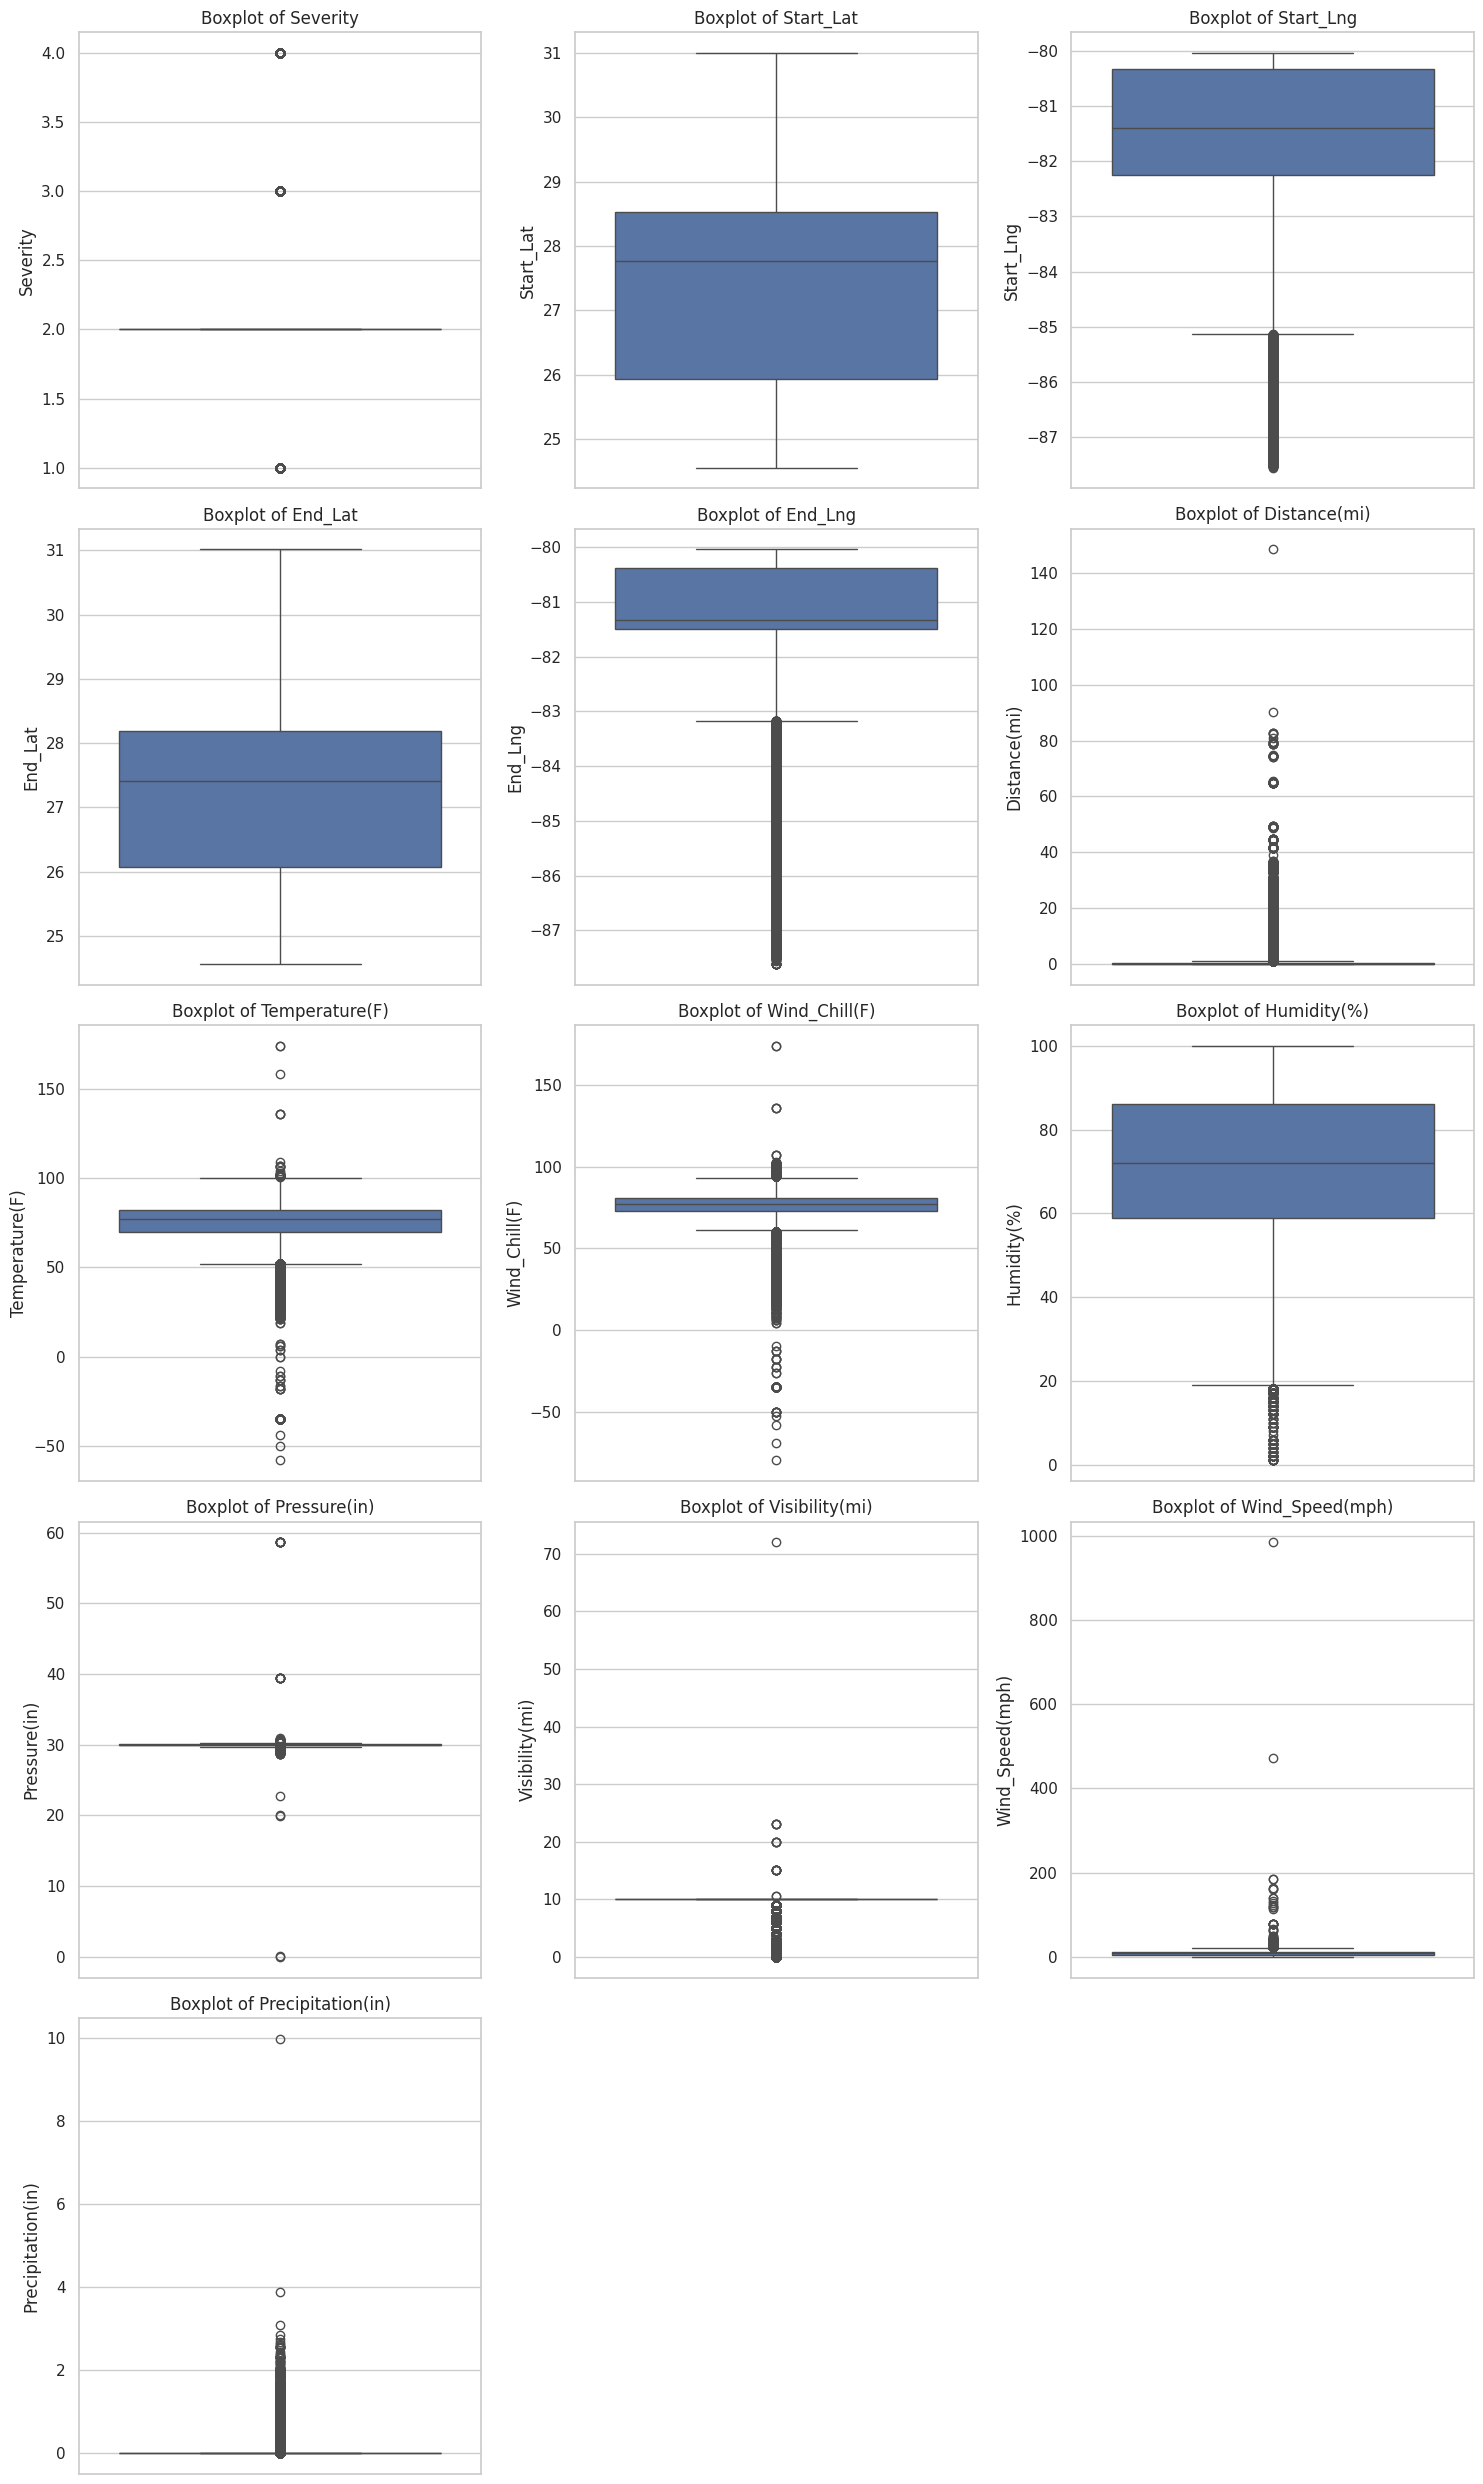

In [48]:
# Create box plots to detect outliers in the original DataFrame
num_features = len(traffic_accidents_raw.select_dtypes(include=['float64', 'int64']).columns)
fig, axes = plt.subplots(nrows=(num_features // 3) + 1, ncols=3, figsize=(15, 5 * ((num_features // 3) + 1)))
axes = axes.flatten()

# Plot boxplots for each numerical feature in df
for i, feature in enumerate(traffic_accidents_raw.select_dtypes(include=['float64', 'int64']).columns):
    sns.boxplot(y=traffic_accidents_raw[feature], ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature}')
    axes[i].set_ylabel(feature)

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

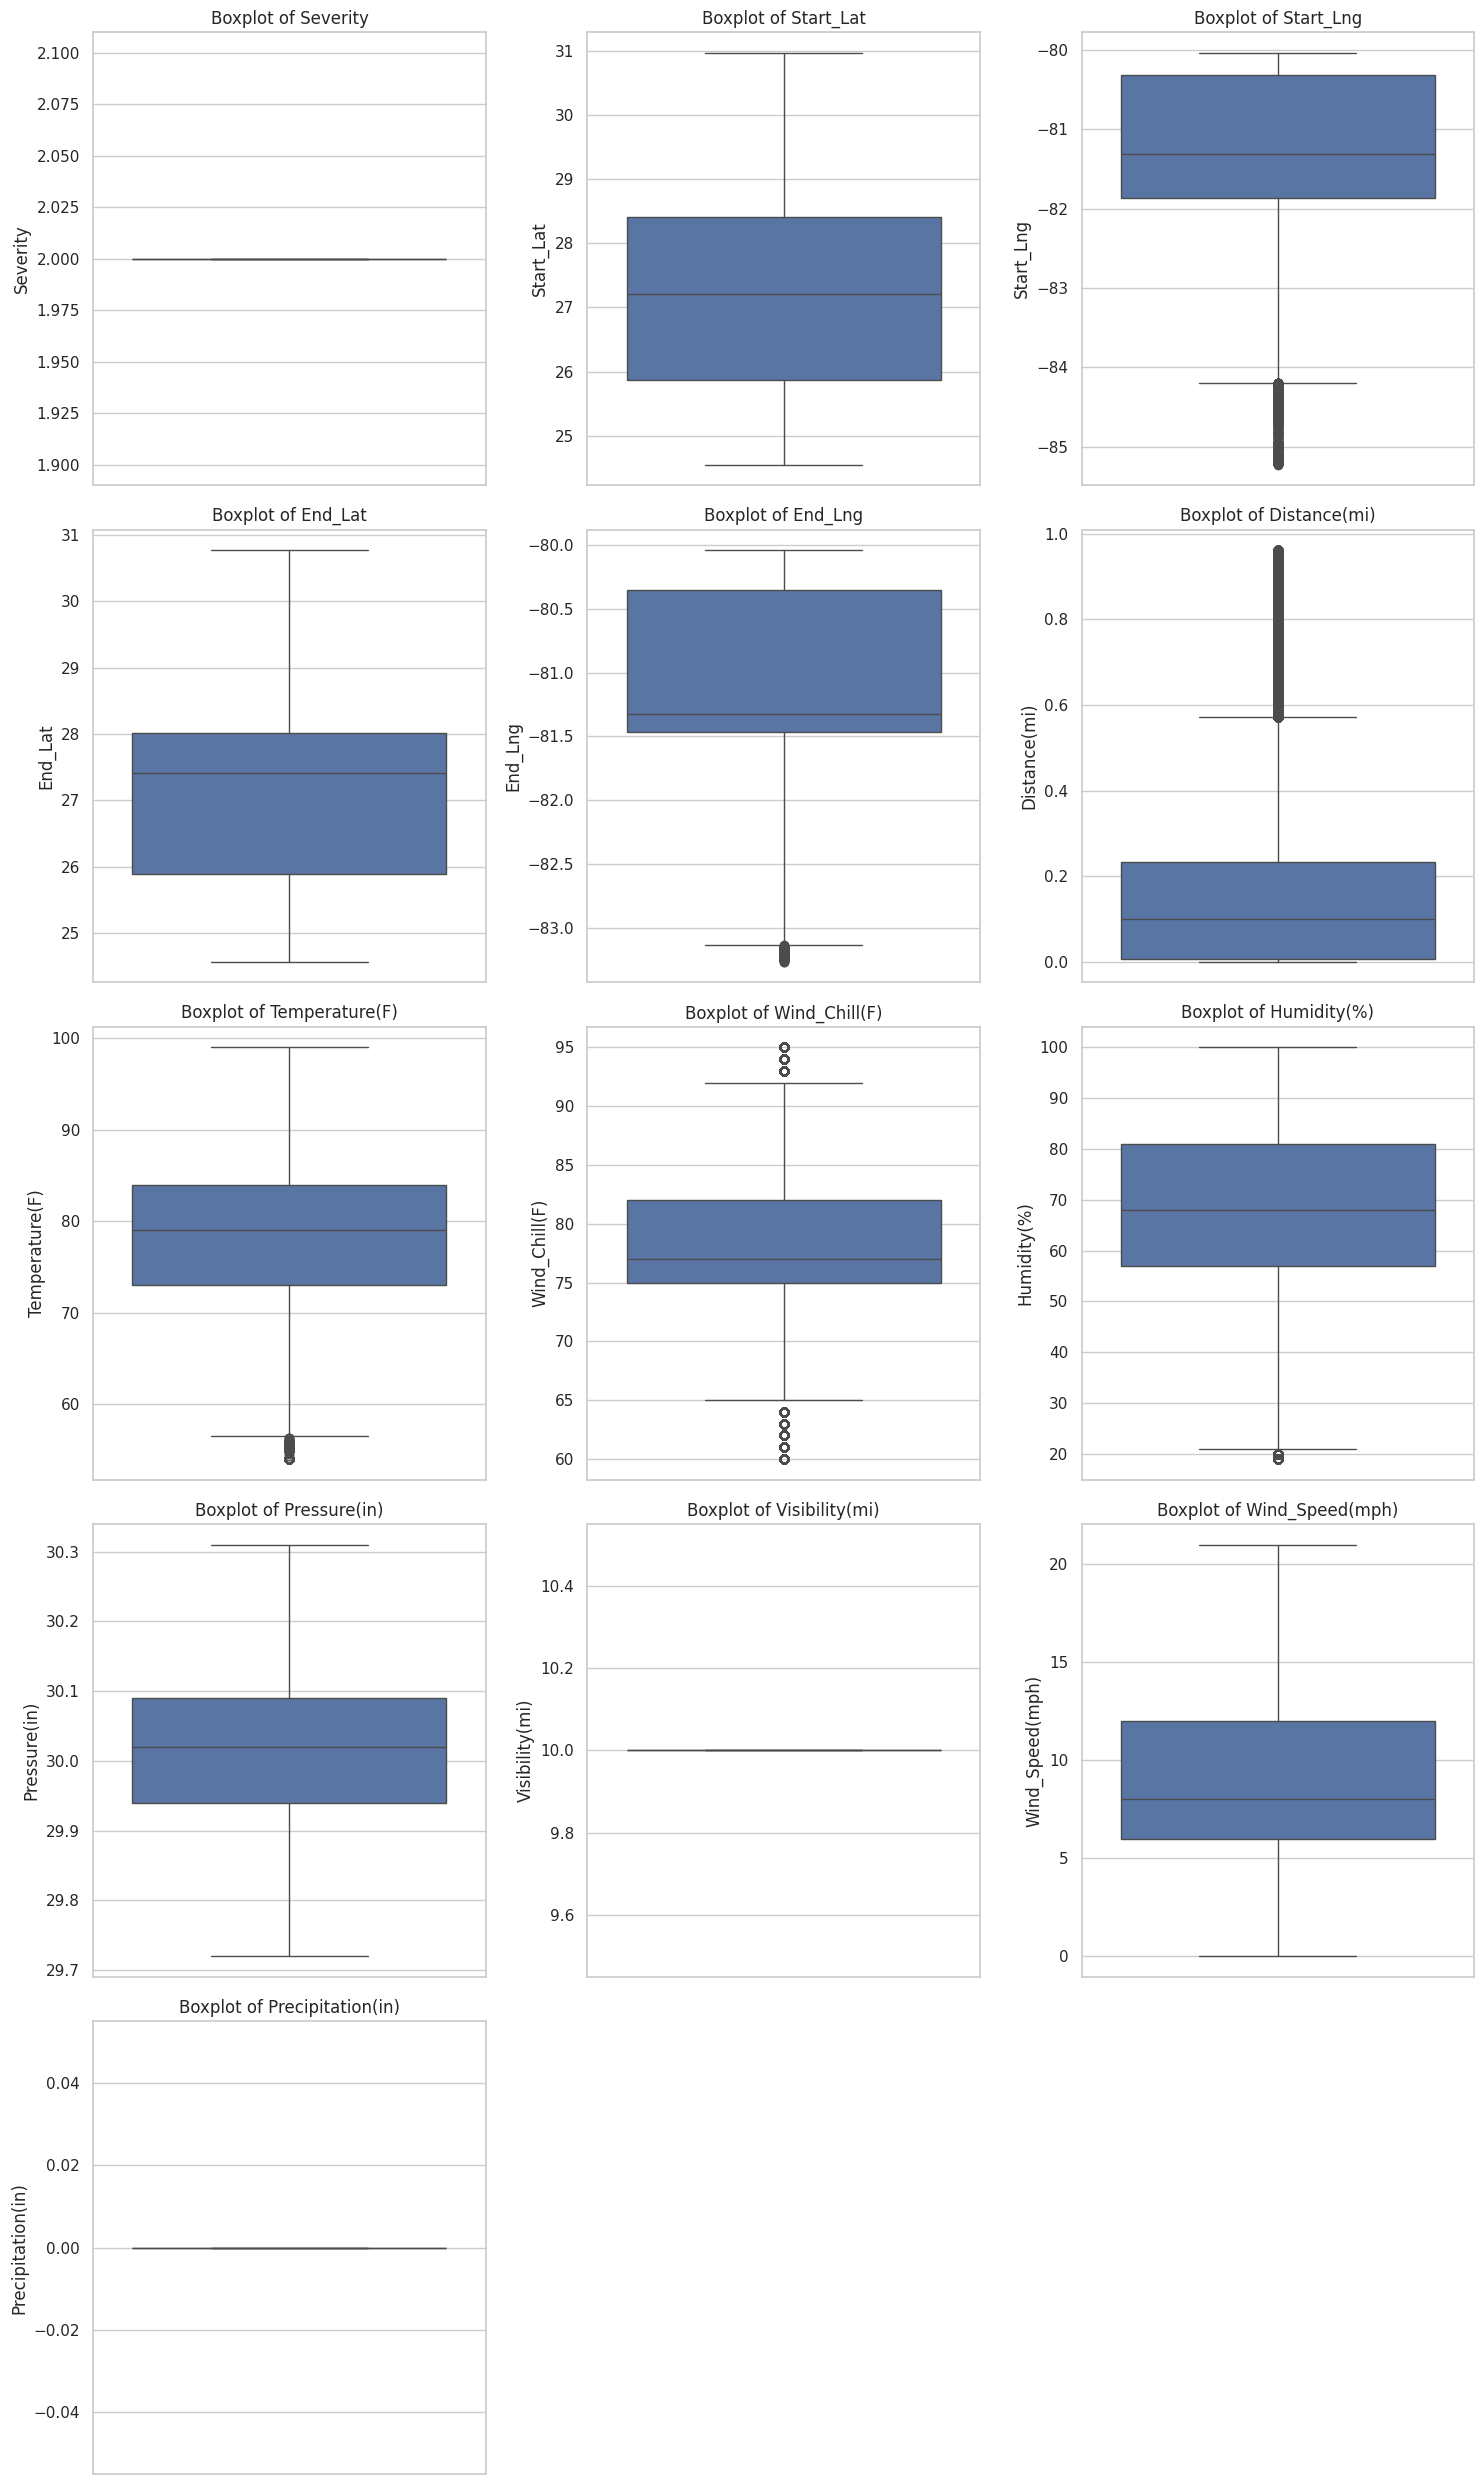

In [49]:
#Initialize a DataFrame to hold the cleaned data
cleaned_df = traffic_accidents_raw.copy()

# Remove outliers using IQR method
for feature in cleaned_df.select_dtypes(include=['float64', 'int64']).columns:
    Q1 = cleaned_df[feature].quantile(0.25)
    Q3 = cleaned_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    cleaned_df = cleaned_df[(cleaned_df[feature] >= lower_bound) & (cleaned_df[feature] <= upper_bound)]

# Create box plots for the cleaned data
num_features = len(cleaned_df.select_dtypes(include=['float64', 'int64']).columns)
fig, axes = plt.subplots(nrows=(num_features // 3) + 1, ncols=3, figsize=(15, 5 * ((num_features // 3) + 1)))
axes = axes.flatten()

# Plot boxplots for each numerical feature in cleaned_df
for i, feature in enumerate(cleaned_df.select_dtypes(include=['float64', 'int64']).columns):
    sns.boxplot(y=cleaned_df[feature], ax=axes[i])
    axes[i].set_title(f'Boxplot of {feature}')
    axes[i].set_ylabel(feature)

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [61]:

dist_cat_columns = traffic_accidents_raw[[
                                            #'ID',
                                            #'Source',
                                            #'Start_Time',
                                            #'End_Time',
                                            #'Description',
                                            'Street',
                                            'City',
                                            'County',
                                            #'State',
                                            #'Zipcode',
                                            #'Country',
                                            #'Timezone',
                                            #'Airport_Code',
                                            #'Weather_Timestamp',
                                            'Wind_Direction',
                                            'Weather_Condition',
                                            'Sunrise_Sunset',
                                            'Civil_Twilight',
                                            'Nautical_Twilight',
                                            'Astronomical_Twilight']
                                          ] # removemos columnas que no agregan valor al analisis por distribución ya que son valores numéricos.

all_frecuencias = {}

for column in dist_cat_columns:

  # Extraemos solo el top 10
  top_10_freq = traffic_accidents_raw[column].str.strip().value_counts()[:10]

  # Crear un DataFrame con la frecuencia y los valores:
  tmp_frecuencias = pd.DataFrame({
      'Columna': column,
      'Valor': top_10_freq.index,
      'Frecuencia': top_10_freq.values
  })
  all_frecuencias[column] = tmp_frecuencias

#convertimos el diccionario en un dataframe
frecuencias_df = pd.concat(all_frecuencias.values(), ignore_index=True)





In [62]:

# Visualización de las frecuencias de los valores de las columnas categóricas
# Iteramos sobre el top ten
for columna in frecuencias_df['Columna'].unique():

    # Filtrar el DataFrame para la columna actual
    df_columna = frecuencias_df[frecuencias_df['Columna'] == columna]

    # Crear el gráfico de barras
    fig = px.bar(
      y=df_columna['Frecuencia'],
      x=df_columna['Valor'],
      color=df_columna['Valor'],
      color_discrete_sequence=px.colors.sequential.PuBuGn,
      text=df_columna['Frecuencia'],
      template='seaborn'    # templates disponibles: ['ggplot2', 'seaborn', 'simple_white', 'plotly', 'plotly_white', 'plotly_dark', 'presentation', 'xgridoff','ygridoff', 'gridon', 'none']
      #link: https://plotly.com/python/templates/
    )

    #
    fig.update_layout(
        #title_text=f'Distribución de Frecuencias para la columna: "{columna}" en los últimos {count_of_years} años',
        title_text=f'Distribución de Frecuencias para la columna: "{columna}" en los últimos años',
        height=700,
        width=1800,
        xaxis_title=columna,
        yaxis_title="Frecuencia",
        font=dict(size=17, family="Franklin Gothic")
    )


    fig.show()
    print("\n")

In [76]:
# ── ETAPA 1 | Análisis Temporal de Ocurrencia ─────────────────────────────────
traffic_accidents_raw['Start_Time'] = pd.to_datetime(
    traffic_accidents_raw['Start_Time'], errors='coerce'
)
traffic_accidents_raw['Hour']    = traffic_accidents_raw['Start_Time'].dt.hour
traffic_accidents_raw['DayOfWeek'] = traffic_accidents_raw['Start_Time'].dt.day_name()
traffic_accidents_raw['Month']   = traffic_accidents_raw['Start_Time'].dt.month_name()

# Orden correcto para días y meses
day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

# -- Por hora del día --
hourly = traffic_accidents_raw.groupby('Hour').size().reset_index(name='Accidentes')
fig = px.bar(hourly, x='Hour', y='Accidentes',
             color='Accidentes', color_continuous_scale='YlOrRd',
             template='seaborn',
             title='Accidentes por Hora del Día — Florida')
fig.update_layout(height=450, width=1000, font=dict(size=13))
fig.show()


In [77]:
# -- Por día de la semana --
daily = (traffic_accidents_raw.groupby('DayOfWeek').size()
         .reindex(day_order).reset_index(name='Accidentes'))
fig2 = px.bar(daily, x='DayOfWeek', y='Accidentes',
              color='Accidentes', color_continuous_scale='YlOrRd',
              template='seaborn',
              title='Accidentes por Día de la Semana — Florida')
fig2.update_layout(height=450, width=1000, font=dict(size=13))
fig2.show()


In [79]:

# -- Por mes --
monthly = (traffic_accidents_raw.groupby('Month').size()
           .reindex(month_order).reset_index(name='Accidentes'))
fig3 = px.bar(monthly, x='Month', y='Accidentes',
              color='Accidentes', color_continuous_scale='YlOrRd',
              template='seaborn',
              title='Accidentes por Mes — Florida')
fig3.update_layout(height=450, width=1000, font=dict(size=13))
fig3.show()



In [80]:
print("=== RESUMEN TEMPORAL ===")
print(f"Hora con más accidentes:       {hourly.loc[hourly['Accidentes'].idxmax(), 'Hour']}:00 hrs")
print(f"Día con más accidentes:        {daily.loc[daily['Accidentes'].idxmax(), 'DayOfWeek']}")
print(f"Mes con más accidentes:        {monthly.loc[monthly['Accidentes'].idxmax(), 'Month']}")

=== RESUMEN TEMPORAL ===
Hora con más accidentes:       8.0:00 hrs
Día con más accidentes:        Friday
Mes con más accidentes:        December


In [81]:
# ── ETAPA 1 | Condiciones Climáticas vs Ocurrencia ────────────────────────────
top_weather = (traffic_accidents_raw['Weather_Condition']
               .value_counts().head(10).reset_index())
top_weather.columns = ['Weather_Condition', 'Accidentes']

fig = px.bar(top_weather, x='Accidentes', y='Weather_Condition',
             orientation='h',
             color='Accidentes', color_continuous_scale='PuBuGn',
             text='Accidentes', template='seaborn',
             title='Top 10 Condiciones Climáticas con Mayor Ocurrencia de Accidentes')
fig.update_layout(height=500, width=1000, font=dict(size=13))
fig.show()

print("=== CONDICIÓN CLIMÁTICA MÁS FRECUENTE EN ACCIDENTES ===")
print(top_weather.head(5).to_string(index=False))

=== CONDICIÓN CLIMÁTICA MÁS FRECUENTE EN ACCIDENTES ===
Weather_Condition  Accidentes
             Fair      326149
    Mostly Cloudy      160791
    Partly Cloudy      121193
           Cloudy       68771
            Clear       59178


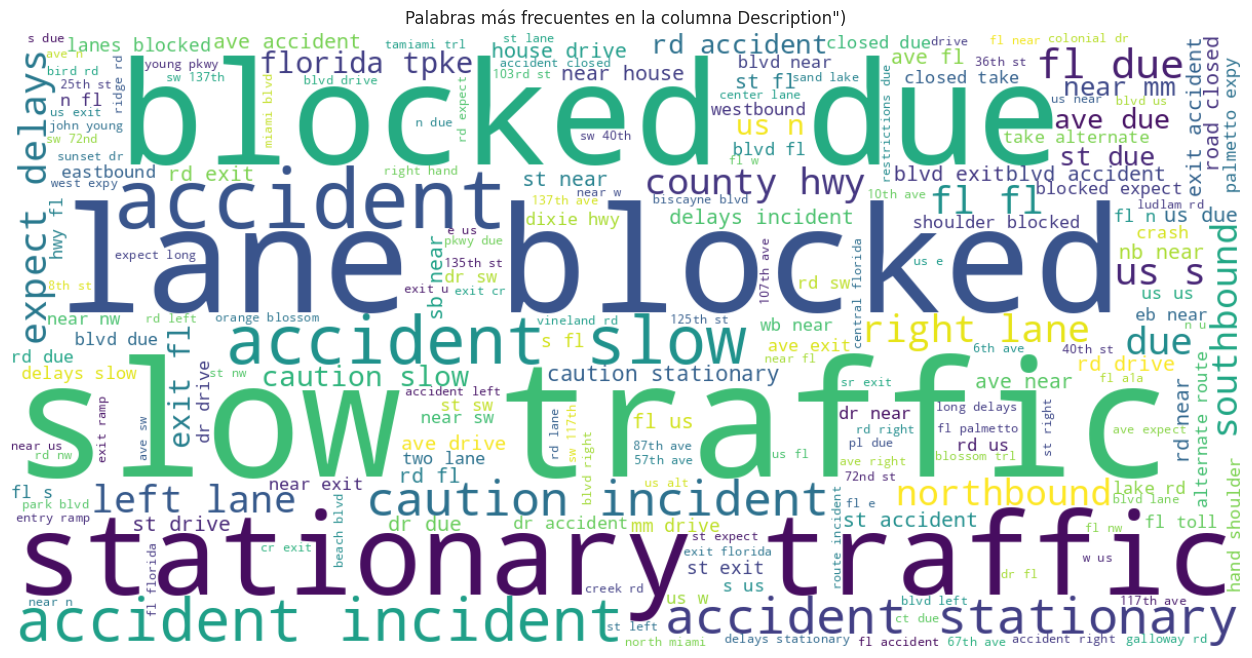

In [63]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Excluir "informacion general" de la nube de palabras
text = ' '.join(traffic_accidents_raw['Description'].dropna().str.strip().str.lower().astype(str))

# Crear el WordCloud
wordcloud = WordCloud(width=1200, height=600, background_color='white', colormap='viridis').generate(text)

# Mostrar el WordCloud
plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palabras más frecuentes en la columna Description")')
plt.show()

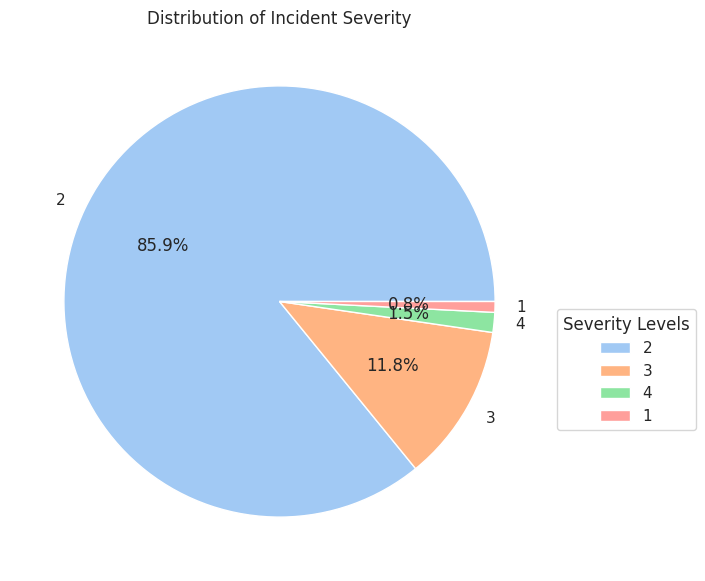

In [64]:
# Count the occurrences of each severity level
severity_count = traffic_accidents_raw['Severity'].value_counts()

# Create the pie chart
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))
pastel_colors = sns.color_palette("pastel", len(severity_count))

plt.pie(
    severity_count,
    labels=severity_count.index,
    autopct='%1.1f%%',
    colors=pastel_colors
)
plt.legend(title='Severity Levels', loc='best', bbox_to_anchor=(1, 0.5))
plt.title('Distribution of Incident Severity')
plt.show()

In [65]:
from sklearn.preprocessing import StandardScaler

# Definir columnas numéricas EXCLUYENDO 'Severity'
scaled_number_columns = [
    'Distance(mi)',
    'Temperature(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)'
    # Agrega todas tus columnas numéricas excepto 'Severity'
]

# Escalamos las columnas numéricas para normalizar los datos
# Esto es útil para algoritmos de machine learning que son sensibles a la escala de los datos
scaler = StandardScaler()
traffic_accidents_scaled = traffic_accidents_raw.copy()
traffic_accidents_scaled[scaled_number_columns] = scaler.fit_transform(traffic_accidents_scaled[scaled_number_columns])

# Verificar que 'Severity' no fue escalada
print("\nValores originales de Severity (no escalados):")
print(traffic_accidents_scaled['Severity'].head(3))

print("\nValores escalados (ejemplo de columna numérica):")
print(traffic_accidents_scaled['Temperature(F)'].head(3))


Valores originales de Severity (no escalados):
0    3
1    3
2    2
Name: Severity, dtype: int64

Valores escalados (ejemplo de columna numérica):
0   0.50
1   0.50
2   0.45
Name: Temperature(F), dtype: float64


In [66]:
# Estadisticas descriptivas de las columnas numéricas escaladas
traffic_accidents_scaled.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00,880192.00
mean,2.14,27.53,-81.48,27.41,-81.38,-0.00,0.00,75.63,-0.00,0.00,0.00,0.00,0.01
std,0.41,1.56,1.44,1.29,1.20,1.00,1.00,9.62,1.00,1.00,1.00,1.00,0.06
min,1.00,24.55,-87.56,24.57,-87.62,-0.32,-12.85,-80.00,-4.11,-183.90,-5.66,-1.68,0.00
25%,2.00,25.93,-82.25,26.07,-81.50,-0.32,-0.52,73.00,-0.72,-0.47,0.29,-0.69,0.00
50%,2.00,27.76,-81.40,27.41,-81.33,-0.26,0.15,77.00,0.04,0.02,0.29,-0.09,0.00
75%,2.00,28.53,-80.32,28.19,-80.38,-0.09,0.64,81.00,0.85,0.45,0.29,0.70,0.00
max,4.00,31.00,-80.04,31.01,-80.04,88.28,9.50,174.00,1.67,175.31,37.17,193.69,9.98


In [74]:
# Crear la columna 'Severity_Level'
traffic_accidents_scaled['Severity_Level'] = pd.cut(
    traffic_accidents_scaled['Severity'],
    bins=[0, 1, 2, 4],
    labels=['Low', 'Moderate', 'High']
)
# Justificación del agrupamiento:
# - Low      → Severidad 1: impacto mínimo en el tráfico
# - Moderate → Severidad 2: impacto significativo pero manejable
# - High     → Severidad 3-4: se agrupan porque ambas representan
#              impacto severo o extremo, y Severidad 4 tiene muy
#              pocos registros para tratarse como clase independiente
print("\nDistribución de Severity_Level:")
print(traffic_accidents_scaled['Severity_Level'].value_counts())


Distribución de Severity_Level:
Severity_Level
Moderate    755895
High        117214
Low           7083
Name: count, dtype: int64


In [57]:
traffic_accidents_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880192 entries, 0 to 880191
Data columns (total 47 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   ID                     880192 non-null  object  
 1   Source                 880192 non-null  object  
 2   Severity               880192 non-null  int64   
 3   Start_Time             880192 non-null  object  
 4   End_Time               880192 non-null  object  
 5   Start_Lat              880192 non-null  float64 
 6   Start_Lng              880192 non-null  float64 
 7   End_Lat                880192 non-null  float64 
 8   End_Lng                880192 non-null  float64 
 9   Distance(mi)           880192 non-null  float64 
 10  Description            880192 non-null  object  
 11  Street                 880192 non-null  object  
 12  City                   880192 non-null  object  
 13  County                 880192 non-null  object  
 14  State               

In [58]:
scaled_categorical_columns = traffic_accidents_scaled.select_dtypes(include = ["object","bool"]).columns.to_list()
scaled_categorical_columns


['ID',
 'Source',
 'Start_Time',
 'End_Time',
 'Description',
 'Street',
 'City',
 'County',
 'State',
 'Zipcode',
 'Country',
 'Timezone',
 'Airport_Code',
 'Weather_Timestamp',
 'Wind_Direction',
 'Weather_Condition',
 'Amenity',
 'Bump',
 'Crossing',
 'Give_Way',
 'Junction',
 'No_Exit',
 'Railway',
 'Roundabout',
 'Station',
 'Stop',
 'Traffic_Calming',
 'Traffic_Signal',
 'Turning_Loop',
 'Sunrise_Sunset',
 'Civil_Twilight',
 'Nautical_Twilight',
 'Astronomical_Twilight']

In [59]:
from sklearn.preprocessing import LabelEncoder

# Crear una copia del DataFrame para evitar modificar el original
df_label_encoded = traffic_accidents_scaled.copy()

# Aplicamos Label Encoding solo a las columnas categóricas filtradas
le = LabelEncoder()
for col in scaled_categorical_columns:
    df_label_encoded[col] = le.fit_transform(df_label_encoded[col].astype(str))

print("Dataset después de aplicar Label Encoding:")
df_label_encoded.head(3)

Dataset después de aplicar Label Encoding:


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Severity_Level
0,15142,1,3,28437,28437,27.98,-82.33,27.41,-81.33,-0.31,305393,31544,525,29,0,57477,0,1,79,8574,0.50,77.00,-0.08,-0.47,0.29,15,-0.53,0.00,37,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,High
1,15153,1,3,28440,28439,27.98,-82.33,27.41,-81.33,-0.31,304709,31544,525,29,0,57477,0,1,79,8576,0.50,77.00,-0.37,-0.47,0.29,22,-0.31,0.00,34,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,High
2,15164,1,2,28444,28438,25.63,-80.37,27.41,-81.33,-0.31,40950,43865,329,44,0,42861,0,1,74,8579,0.45,77.00,-0.02,-0.34,0.29,13,0.15,0.00,34,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,Moderate


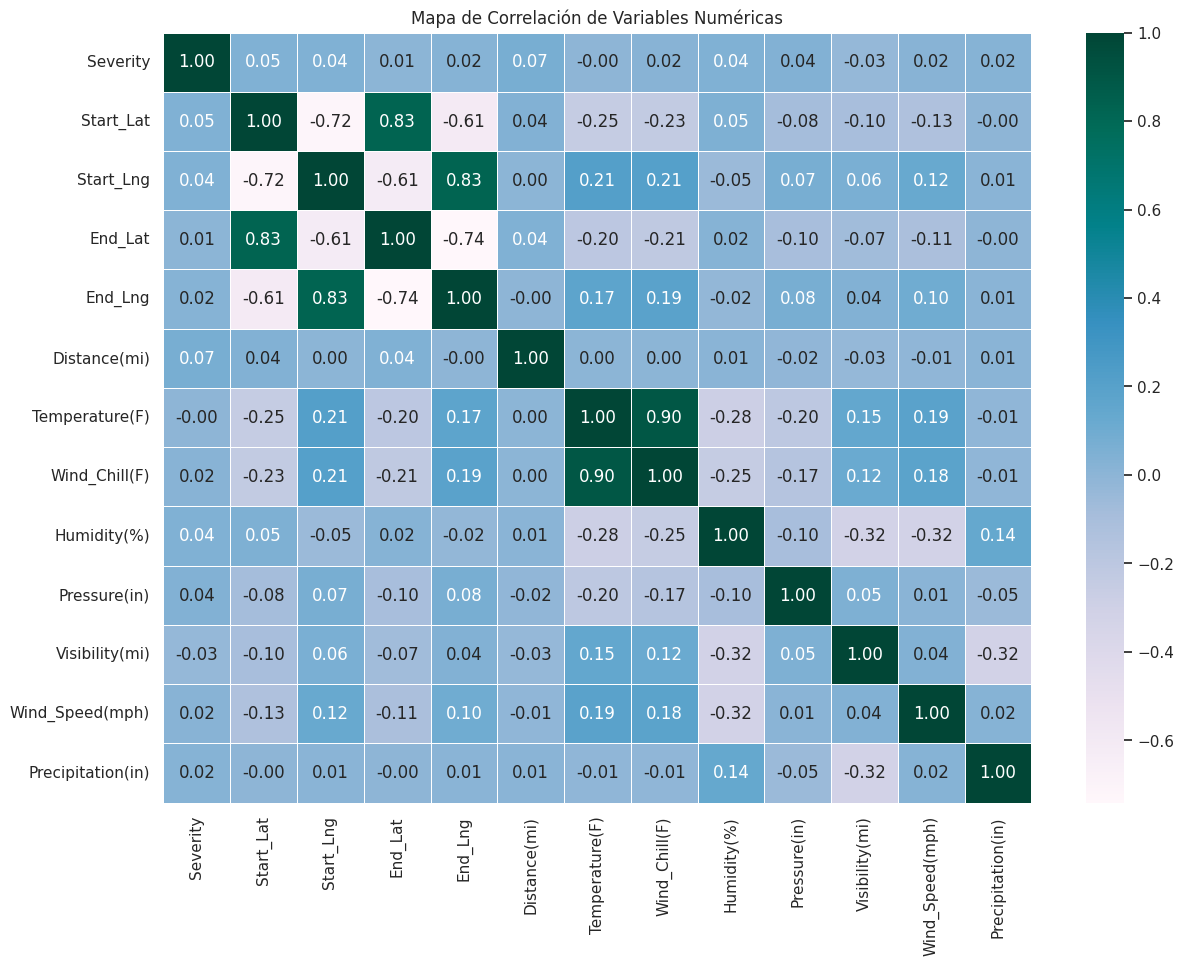

In [60]:
# Mapa de correlación para las variables numéricas
corr_matrix = df_label_encoded[number_columns].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='PuBuGn', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Correlación de Variables Numéricas')
plt.show()

In [82]:
# ── ETAPA 2 | Severidad por Hora del Día ─────────────────────────────────────
if 'Hour' not in traffic_accidents_raw.columns:
    traffic_accidents_raw['Hour'] = pd.to_datetime(
        traffic_accidents_raw['Start_Time'], errors='coerce').dt.hour

severity_hour = (traffic_accidents_raw
                 .groupby('Hour')['Severity']
                 .mean().reset_index(name='Severidad_Promedio'))

fig = px.line(severity_hour, x='Hour', y='Severidad_Promedio',
              markers=True, template='seaborn',
              title='Severidad Promedio por Hora del Día — Florida',
              labels={'Hour': 'Hora', 'Severidad_Promedio': 'Severidad Promedio'})
fig.update_traces(line_color='#e63946', line_width=2)
fig.update_layout(height=450, width=1000, font=dict(size=13))
fig.show()

hora_critica = severity_hour.loc[severity_hour['Severidad_Promedio'].idxmax()]
print(f"Hora con mayor severidad promedio: {int(hora_critica['Hour'])}:00 hrs "
      f"(severidad: {hora_critica['Severidad_Promedio']:.2f})")

Hora con mayor severidad promedio: 20:00 hrs (severidad: 2.23)


In [83]:
# ── ETAPA 2 | Severidad por Condición Climática ───────────────────────────────
severity_weather = (traffic_accidents_raw
                    .groupby('Weather_Condition')
                    .agg(
                        Severidad_Promedio=('Severity', 'mean'),
                        Total_Accidentes=('Severity', 'count')
                    )
                    .reset_index()
                    .query('Total_Accidentes >= 100')  # filtrar condiciones con poca muestra
                    .sort_values('Severidad_Promedio', ascending=False)
                    .head(15))

fig = px.bar(severity_weather, x='Severidad_Promedio', y='Weather_Condition',
             orientation='h',
             color='Severidad_Promedio',
             color_continuous_scale='YlOrRd',
             text=severity_weather['Severidad_Promedio'].round(2),
             template='seaborn',
             title='Top 15 Condiciones Climáticas por Severidad Promedio<br>'
                   '<sup>(solo condiciones con 100+ accidentes)</sup>')
fig.update_layout(height=550, width=1050, font=dict(size=13))
fig.show()

print("=== CONDICIÓN CLIMÁTICA CON MAYOR SEVERIDAD PROMEDIO ===")
print(severity_weather[['Weather_Condition','Severidad_Promedio',
                         'Total_Accidentes']].head(5).to_string(index=False))

=== CONDICIÓN CLIMÁTICA CON MAYOR SEVERIDAD PROMEDIO ===
           Weather_Condition  Severidad_Promedio  Total_Accidentes
      Thunderstorms and Rain                2.51               498
Heavy Thunderstorms and Rain                2.46               641
Light Thunderstorms and Rain                2.45              1130
                Thunderstorm                2.43              1531
                    Overcast                2.40             15900


In [84]:
# ── ETAPA 2 | Severidad por Condado ──────────────────────────────────────────
severity_county = (traffic_accidents_raw
                   .groupby('County')
                   .agg(
                       Severidad_Promedio=('Severity', 'mean'),
                       Total_Accidentes=('Severity', 'count')
                   )
                   .reset_index()
                   .query('Total_Accidentes >= 50')
                   .sort_values('Severidad_Promedio', ascending=False)
                   .head(20))

fig = px.bar(severity_county, x='County', y='Severidad_Promedio',
             color='Severidad_Promedio',
             color_continuous_scale='YlOrRd',
             text=severity_county['Severidad_Promedio'].round(2),
             template='seaborn',
             title='Top 20 Condados por Severidad Promedio de Accidentes — Florida<br>'
                   '<sup>(solo condados con 50+ accidentes)</sup>')
fig.update_layout(height=500, width=1100, font=dict(size=13))
fig.show()

print("=== CONDADOS CON MAYOR SEVERIDAD PROMEDIO ===")
print(severity_county[['County','Severidad_Promedio',
                        'Total_Accidentes']].head(10).to_string(index=False))

=== CONDADOS CON MAYOR SEVERIDAD PROMEDIO ===
    County  Severidad_Promedio  Total_Accidentes
     Duval                2.40             41726
  Hamilton                2.38               943
 St. Lucie                2.35              2808
   Flagler                2.34              1176
   Broward                2.33             53865
    Monroe                2.33              1349
Palm Beach                2.31             30931
    Glades                2.31               191
  Suwannee                2.31              1511
 Charlotte                2.30              2311


In [88]:
# ── ETAPA 2 | Resumen Integrado: Ocurrencia + Severidad por Condado ───────────
# Este análisis conecta ambas etapas del modelo
resumen_county = (traffic_accidents_raw
                  .groupby('County')
                  .agg(
                      Ocurrencias=('Severity', 'count'),
                      Severidad_Promedio=('Severity', 'mean')
                  )
                  .reset_index())

# Clasificar riesgo de ocurrencia
def clasificar_riesgo(serie):
    p25 = serie.quantile(0.25)
    p50 = serie.quantile(0.50)
    p75 = serie.quantile(0.75)
    def nivel(val):
        if val <= p25:   return 'Bajo'
        elif val <= p50: return 'Moderado'
        elif val <= p75: return 'Alto'
        else:            return 'Crítico'
    return serie.apply(nivel)

resumen_county['Riesgo_Ocurrencia'] = clasificar_riesgo(resumen_county['Ocurrencias'])

# Clasificar nivel de severidad promedio
resumen_county['Nivel_Severidad'] = pd.cut(
    resumen_county['Severidad_Promedio'],
    bins=[0, 1.5, 2.0, 2.5, 4],
    labels=['Baja', 'Moderada', 'Alta', 'Crítica']
)

fig = px.scatter(resumen_county,
                 x='Ocurrencias', y='Severidad_Promedio',
                 color='Riesgo_Ocurrencia',
                 size='Ocurrencias',
                 hover_name='County',
                 color_discrete_map={
                     'Bajo': '#a8d5a2',
                     'Moderado': '#f6d860',
                     'Alto': '#f4a261',
                     'Crítico': '#e63946'
                 },
                 template='seaborn',
                 title='Relación entre Ocurrencia y Severidad por Condado — Florida<br>'
                       '<sup>Cada punto es un condado. Tamaño = número de accidentes</sup>')
fig.update_layout(height=550, width=1000, font=dict(size=13))
fig.show()

print("=== PERFIL DE RIESGO COMPLETO POR CONDADO (Top 15) ===")
display(resumen_county.sort_values('Ocurrencias', ascending=False)
        .head(15)[['County','Ocurrencias','Riesgo_Ocurrencia',
                   'Severidad_Promedio','Nivel_Severidad']]
        .reset_index(drop=True))

=== PERFIL DE RIESGO COMPLETO POR CONDADO (Top 15) ===


,County,Ocurrencias,Riesgo_Ocurrencia,Severidad_Promedio,Nivel_Severidad
0,Miami-Dade,251601,Crítico,2.09,Alta
1,Orange,124321,Crítico,2.08,Alta
2,Broward,53865,Crítico,2.33,Alta
3,Hillsborough,52623,Crítico,2.20,Alta
4,Duval,41726,Crítico,2.40,Alta
5,Pinellas,41387,Crítico,2.06,Alta
6,Lee,34554,Crítico,2.06,Alta
7,Palm Beach,30931,Crítico,2.31,Alta
8,Manatee,22153,Crítico,2.09,Alta
9,Sarasota,20675,Crítico,2.09,Alta


### Setup del modelo

In [102]:
# ── MODELADO | Setup ──────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, accuracy_score)

### 🛠️ RandomForestClassifier

In [103]:
# ── Preparación de variables para el modelo ───────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Usar el dataset con encoding ya aplicado
df = df_label_encoded.copy()

# 2. Agregar variable Hour si no existe
if 'Hour' not in df.columns:
    df['Hour'] = pd.to_datetime(
        traffic_accidents_scaled['Start_Time'], errors='coerce'
    ).dt.hour

# 3. Seleccionar columnas relevantes
cols = [
    "Severity",
    # Geográficas
    "Start_Lat", "Start_Lng", "Street", "City", "County",
    # Infraestructura vial
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction",
    "No_Exit", "Railway", "Roundabout", "Station", "Stop",
    "Traffic_Calming", "Traffic_Signal", "Turning_Loop",
    # Climáticas
    "Wind_Chill(F)", "Temperature(F)", "Humidity(%)",
    "Visibility(mi)", "Wind_Speed(mph)",
    "Weather_Condition", "Precipitation(in)",
    # Temporal
    "Hour"
]
df = df[cols].dropna()

# 4. Codificar Weather_Condition
df = pd.get_dummies(df, columns=["Weather_Condition"], drop_first=True)

# 5. Variable objetivo — 3 categorías consistente con EDA
df["Target"] = pd.cut(
    df["Severity"],
    bins=[0, 1, 2, 4],
    labels=['Low', 'Moderate', 'High']
)
df = df.drop(columns=["Severity"])
df = df.dropna(subset=["Target"])

print("Distribución de la variable objetivo:")
print(df["Target"].value_counts())

# 6. X e y — SIN split todavía, primero balancear
X = df.drop("Target", axis=1)
y = df["Target"]

Distribución de la variable objetivo:
Target
Moderate    642070
High        116472
Low           7083
Name: count, dtype: int64


In [104]:
# ── Balanceo de clases (Undersampling) ────────────────────────────────────────
print("Distribución antes del balanceo:")
print(y.value_counts())

min_class_count = y.value_counts().min()

df_balanced = pd.concat([X, y], axis=1)
df_balanced = (
    df_balanced
    .groupby('Target', group_keys=False)
    .apply(lambda x: x.sample(n=min_class_count, random_state=42))
    .reset_index(drop=True)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

X = df_balanced.drop(columns=['Target'])
y = df_balanced['Target']

print(f"\nDistribución después del balanceo:")
print(y.value_counts())
print(f"\nTotal registros balanceados: {len(df_balanced):,}")

# ── Split 80/20 DESPUÉS del balanceo ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"\nTraining Set: {len(X_train):,} registros")
print(f"Test Set:     {len(X_test):,} registros")

Distribución antes del balanceo:
Target
Moderate    642070
High        116472
Low           7083
Name: count, dtype: int64


/tmp/ipykernel_586/736137603.py:10: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.




Distribución después del balanceo:
Target
Low         7083
Moderate    7083
High        7083
Name: count, dtype: int64

Total registros balanceados: 21,249

Training Set: 16,999 registros
Test Set:     4,250 registros


/tmp/ipykernel_586/736137603.py:11: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [107]:
# ── MODELADO | Random Forest ──────────────────────────────────────────────────
print("=" * 55)
print("           RANDOM FOREST CLASSIFIER")
print("=" * 55)

rf = RandomForestClassifier(n_estimators=100,
                            random_state=42,
                            class_weight='balanced',
                            n_jobs=-1)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Validación cruzada
cv_scores_rf = cross_val_score(rf, X_train, y_train, cv=kf, scoring='accuracy')
print(f"\n📊 Validación Cruzada (5-Fold):")
print(f"   Scores:  {cv_scores_rf.round(4)}")
print(f"   Media:   {cv_scores_rf.mean():.4f}")
print(f"   Std:     {cv_scores_rf.std():.4f}")

# Entrenamiento y evaluación
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)  # multiclase: no usar [:,1]

print(f"\n📋 Evaluación en Test Set:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print(f"ROC AUC:  {roc_auc_score(y_test, y_prob_rf, multi_class='ovr', average='weighted'):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

           RANDOM FOREST CLASSIFIER

📊 Validación Cruzada (5-Fold):
   Scores:  [0.7432 0.7618 0.7553 0.7588 0.7455]
   Media:   0.7529
   Std:     0.0073

📋 Evaluación en Test Set:
Confusion Matrix:
 [[1147  115  154]
 [ 124 1179  114]
 [ 312  180  925]]

Classification Report:
               precision    recall  f1-score   support

        High       0.72      0.81      0.76      1416
         Low       0.80      0.83      0.82      1417
    Moderate       0.78      0.65      0.71      1417

    accuracy                           0.76      4250
   macro avg       0.77      0.76      0.76      4250
weighted avg       0.77      0.76      0.76      4250

ROC AUC:  0.9065
Accuracy: 0.7649


### 🛠️ LightGBM (Light Gradient Boosting Machine)

In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

# Split inicial (como ya lo tienes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Entrena LightGBM
lgb_classifier = lgb.LGBMClassifier(random_state=42)
lgb_classifier.fit(X_train, y_train)

# Predice en TEST, igual que RandomForest
y_pred = lgb_classifier.predict(X_test)
y_prob = lgb_classifier.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC AUC:", roc_auc_score(y_test, y_prob))
print("\nAccuracy:",accuracy_score(y_val, lgb_predictions))


[LightGBM] [Info] Number of positive: 530979, number of negative: 4958
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017160 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1831
[LightGBM] [Info] Number of data points in the train set: 535937, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.990749 -> initscore=4.673720
[LightGBM] [Info] Start training from score 4.673720
Confusion Matrix:
 [[    78   2047]
 [   133 227430]]

Classification Report:
               precision    recall  f1-score   support

           0       0.37      0.04      0.07      2125
           1       0.99      1.00      1.00    227563

    accuracy                           0.99    229688
   macro avg       0.68      0.52      0.53    229688
weighted avg       0.99      0.99      0.99    229688


ROC AUC: 0.9269452487753229

Accurac

### 🛠️ SVM lineal

In [ ]:
from sklearn.linear_model import SGDClassifier

# 1. Entrenar SVM lineal
sgd_classifier = SGDClassifier(random_state=42, loss='hinge')  # hinge = SVM, log = logistic regression
sgd_classifier.fit(X_train, y_train)

# 2. Predecir sobre X_test (igual que RF y LGBM)
sgd_predictions = sgd_classifier.predict(X_test)

# 3. Para ROC AUC
sgd_scores = sgd_classifier.decision_function(X_test)

# 4. Métricas iguales
print("Confusion Matrix:\n", confusion_matrix(y_test, sgd_predictions))
print("\nClassification Report:\n", classification_report(y_test, sgd_predictions))
print("\nROC AUC:", roc_auc_score(y_test, sgd_scores))
print("\nAccuracy:", accuracy_score(y_test, sgd_predictions))


Confusion Matrix:
 [[     0   2125]
 [     0 227563]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      2125
           1       0.99      1.00      1.00    227563

    accuracy                           0.99    229688
   macro avg       0.50      0.50      0.50    229688
weighted avg       0.98      0.99      0.99    229688


ROC AUC: 0.41842982434599235

Accuracy: 0.9907483194594406


c:\Users\edegr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\edegr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\edegr\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [ ]:
# ── Índice de Riesgo por Frecuencia de Ocurrencias ───────────────────────────
import plotly.express as px
import pandas as pd

# ── Función reutilizable de clasificación de riesgo ───────────────────────────
def clasificar_riesgo(serie):
    p25 = serie.quantile(0.25)
    p50 = serie.quantile(0.50)
    p75 = serie.quantile(0.75)

    def nivel(val):
        if val <= p25: return 'Bajo'
        elif val <= p50: return 'Moderado'
        elif val <= p75: return 'Alto'
        else: return 'Crítico'

    return serie.apply(nivel)

color_riesgo = {
    'Bajo': '#a8d5a2',
    'Moderado': '#f6d860',
    'Alto': '#f4a261',
    'Crítico': '#e63946'
}

# ── NIVEL 1: Por Condado (County) ─────────────────────────────────────────────
county_risk = (
    traffic_accidents_raw
    .groupby('County')
    .agg(
        ocurrencias=('Severity', 'count'),
        severidad_promedio=('Severity', 'mean')
    )
    .reset_index()
    .sort_values('ocurrencias', ascending=False)
)

county_risk['nivel_riesgo'] = clasificar_riesgo(county_risk['ocurrencias'])

print("=== TOP 20 CONDADOS POR RIESGO ===")
display(county_risk.head(20))

fig = px.bar(
    county_risk.head(20),
    x='County', y='ocurrencias',
    color='nivel_riesgo',
    color_discrete_map=color_riesgo,
    text='ocurrencias',
    template='seaborn',
    title='Top 20 Condados — Nivel de Riesgo por Frecuencia de Accidentes'
)
fig.update_layout(height=550, width=1100, font=dict(size=13))
fig.show()


# ── NIVEL 2: Por Coordenadas (Lat/Long redondeadas) ───────────────────────────
traffic_accidents_raw['lat_round'] = traffic_accidents_raw['Start_Lat'].round(2)
traffic_accidents_raw['lng_round'] = traffic_accidents_raw['Start_Lng'].round(2)

coord_risk = (
    traffic_accidents_raw
    .groupby(['lat_round', 'lng_round'])
    .agg(
        ocurrencias=('Severity', 'count'),
        severidad_promedio=('Severity', 'mean')
    )
    .reset_index()
    .sort_values('ocurrencias', ascending=False)
)

coord_risk['nivel_riesgo'] = clasificar_riesgo(coord_risk['ocurrencias'])

print("\n=== TOP 20 PUNTOS GEOGRÁFICOS POR RIESGO ===")
display(coord_risk.head(20))


# ── NIVEL 3: Mapa de calor geográfico ─────────────────────────────────────────
top_coords = coord_risk[coord_risk['ocurrencias'] >= coord_risk['ocurrencias'].quantile(0.90)]

fig2 = px.density_mapbox(
    top_coords,
    lat='lat_round',
    lon='lng_round',
    z='ocurrencias',
    radius=8,
    center={"lat": 37.5, "lon": -96},
    zoom=3,
    mapbox_style="carto-positron",
    color_continuous_scale='YlOrRd',
    title='Mapa de Calor — Zonas de Mayor Riesgo por Frecuencia de Accidentes'
)
fig2.update_layout(height=600, width=1100, font=dict(size=13))
fig2.show()


# ── RESUMEN DE NIVELES DE RIESGO ──────────────────────────────────────────────
print("\n=== DISTRIBUCIÓN DE NIVELES DE RIESGO (por punto geográfico) ===")
print(coord_risk['nivel_riesgo'].value_counts())

print("\n=== UMBRALES DE OCURRENCIAS POR NIVEL ===")
for nivel in ['Bajo', 'Moderado', 'Alto', 'Crítico']:
    subset = coord_risk[coord_risk['nivel_riesgo'] == nivel]['ocurrencias']
    if not subset.empty:
        print(f"{nivel:10s}: {int(subset.min()):>5} – {int(subset.max()):>6} accidentes")

=== TOP 20 CONDADOS POR RIESGO ===


,County,ocurrencias,severidad_promedio,nivel_riesgo
44,Miami-Dade,251601,2.09,Crítico
49,Orange,124321,2.08,Crítico
5,Broward,53865,2.33,Crítico
29,Hillsborough,52623,2.20,Crítico
16,Duval,41726,2.40,Crítico
53,Pinellas,41387,2.06,Crítico
36,Lee,34554,2.06,Crítico
51,Palm Beach,30931,2.31,Crítico
41,Manatee,22153,2.09,Crítico
59,Sarasota,20675,2.09,Crítico



=== TOP 20 PUNTOS GEOGRÁFICOS POR RIESGO ===


,lat_round,lng_round,ocurrencias,severidad_promedio,nivel_riesgo
13243,28.45,-81.47,3847,2.04,Crítico
1304,25.89,-80.16,3112,2.00,Crítico
13242,28.45,-81.48,2896,2.00,Crítico
1451,25.94,-80.19,2709,2.41,Crítico
13250,28.45,-81.40,2611,2.00,Crítico
1301,25.89,-80.19,2573,2.00,Crítico
1244,25.87,-80.21,2533,2.42,Crítico
1329,25.90,-80.21,2482,2.49,Crítico
1415,25.93,-80.21,2439,2.39,Crítico
1597,25.99,-80.17,2257,2.53,Crítico



=== DISTRIBUCIÓN DE NIVELES DE RIESGO (por punto geográfico) ===
nivel_riesgo
Moderado    8360
Bajo        7942
Crítico     7164
Alto        5895
Name: count, dtype: int64

=== UMBRALES DE OCURRENCIAS POR NIVEL ===
Bajo      :     1 –      1 accidentes
Moderado  :     2 –      4 accidentes
Alto      :     5 –     13 accidentes
Crítico   :    14 –   3847 accidentes
